# Best Enzyme activity from training

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import config

df = pd.read_csv(config.TRAINING_DATA_LOGS_FILENAME)
last_experiment_number = int(df['experiment_number'].iloc[-1])
max_enzyme_activity = 0
max_enzyme_experiment_num = 0

for experiment_number in range(1, last_experiment_number+1):
    enzyme_activity = list(df.loc[df['experiment_number'] == experiment_number, 'enzyme_activity'])

    if max(enzyme_activity) > max_enzyme_activity:
        max_enzyme_activity = max(enzyme_activity)
        max_enzyme_experiment_num = experiment_number


best_result_df = df[df['experiment_number'] == max_enzyme_experiment_num]

print(f"Max enzyme activity: {max_enzyme_activity}")
print(f"Max Enzyme Activity found in Experiment: {max_enzyme_experiment_num}")

Max enzyme activity: 3.152003271741413
Max Enzyme Activity found in Experiment: 10255


# Change in cells

0.02022431722762265


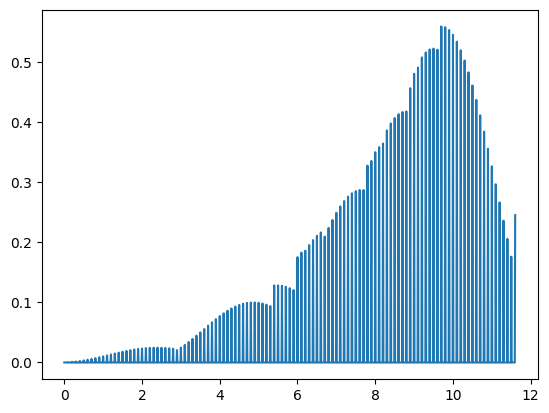

In [27]:
change = best_result_df['change']
tvec = best_result_df['timestep']/100
change = change * tvec
print(sum(change)/len(change))

plt.plot(tvec, change)

# Plotting Best Experiment results

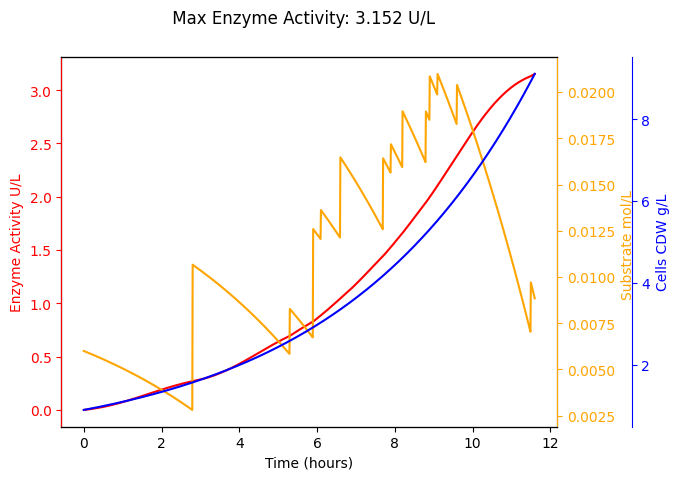

In [28]:
tvec = best_result_df['timestep']/100
E = best_result_df['enzyme_activity']
S = best_result_df['substrate_in_tank']
X = best_result_df['biomass']
flow_vol = best_result_df['feeding_action']


fig, ax1 = plt.subplots()
fig.suptitle(f" Max Enzyme Activity: {round(max(E),3)} U/L" )
ax1.plot(tvec,E ,color="red", label= "Enzyme Activity U/L")

ax2 = ax1.twinx()
ax2.plot(tvec, S, color="orange", label="Substrate mol/L")

ax3 = ax1.twinx()
ax3.plot(tvec , X ,color="blue", label="Cells CDW g/L")
ax3.spines['right'].set_position(('outward',60))
ax3.spines['right'].set_position(('axes',1.15))

ax1.set_ylabel("Enzyme Activity U/L", color="red")
ax1.set_xlabel("Time (hours)")
ax2.set_ylabel("Substrate mol/L ", color="orange")
ax3.set_ylabel("Cells CDW g/L", color="blue")

ax1.tick_params(axis='y',colors="red")
ax2.tick_params(axis='y',colors="orange")
ax3.tick_params(axis='y',colors="blue")

ax2.spines['right'].set_color("orange")
ax3.spines['right'].set_color("blue")
ax3.spines['left'].set_color("red")
#fig.legend()
plt.show()

# Substrate to cell ratio of the best experiement

6688.963210702341
6666.107186804874
6643.296783713685
6620.531910369089
6597.81247589354
6575.138389590528
6552.509560944813
6529.925899621769
6507.387315466967
6484.893718506175
6462.445018944491
6440.041127166365
6417.681953735059
6395.36740939244
6373.097405058556
6350.871851831115
6328.690660985274
6306.553743973542
6284.461012424833
6262.412378144792
6240.407753114739
6218.447049491902
6196.530179608888
6174.657055973175
6152.827591266792
6131.041698346353
6109.299290241994
6087.600280157932
6065.9445814711
6044.3321077319015
6022.762772662759
6001.236490158645
5979.753174286276
5958.312739283805
5936.915099560948
5915.560169697745
5894.247864445005
5872.978098723797
5851.7507876246445
5830.565846408059
5809.423190503219
5788.322735508399
5767.264397190279
5746.248091483436
5725.273734490688
5704.341242481879
5683.450531894308
5662.601519331842
5641.794121564927
5621.0282555300055
5600.303838329544
5579.620787231242
5558.979019668154
5538.378453237812
5517.819005702646
5497.300594

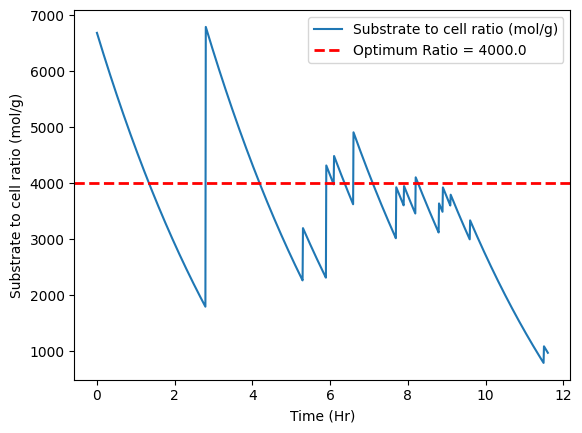

In [29]:
plt.plot(tvec, (S/X)* 1e6, label="Substrate to cell ratio (mol/g)")
plt.xlabel("Time (Hr)")
plt.ylabel("Substrate to cell ratio (mol/g)")
#plt.title(f"Average substrate to cell ratio: {sum(S/X)/len(S/X)} (mol/g)")
plt.axhline(y=config.OPT_SUB_CELL_RATIO * 1e6, color='r', linestyle='--', linewidth=2, label=f'Optimum Ratio = {config.OPT_SUB_CELL_RATIO * 1e6}')
plt.legend()

scr = (S/X) * 1e6

for i in scr:
    print(i)
# for i, j in zip(S, X):
#     print(f"Substrate: {i}, cells: {j}")
#     print("Ratio: ",i/j)

# Flow Volume

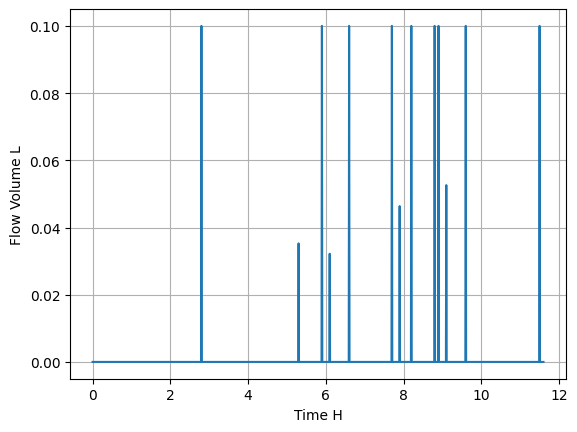

In [30]:
plt.plot(tvec, flow_vol)
plt.xlabel("Time H")
plt.ylabel("Flow Volume L")
plt.grid(True)

# Best experiment Reward

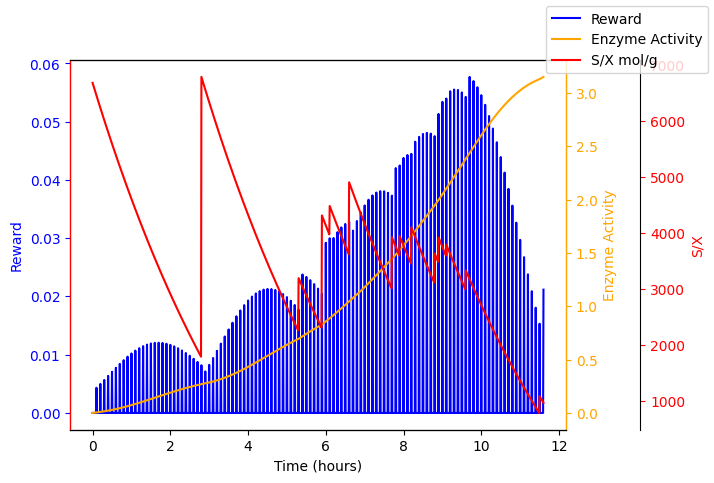

In [31]:
non_zero_result = best_result_df
tsteps = non_zero_result['timestep']
bst_reward = non_zero_result['reward']
bst_enzy_actv = non_zero_result['enzyme_activity']
bst_cells = non_zero_result['biomass']
bst_subtrate = non_zero_result['substrate_in_tank']

fig, ax1 = plt.subplots()
#fig.suptitle(f"Max Enzyme: {round(max(bst_enzy_actv),2)} U/L ,cumulative reward : {sum(bst_reward)}")
ax1.plot(tsteps/100, bst_reward ,color="blue", label= "Reward")

ax2 = ax1.twinx()
ax2.plot(tsteps/100, bst_enzy_actv, color="orange", label="Enzyme Activity")

ax3 = ax1.twinx()
ax3.plot(tsteps/100 , (bst_subtrate/bst_cells)*1e6  ,color="red", label="S/X mol/g")
ax3.spines['right'].set_position(('axes',1.15))

ax1.set_ylabel("Reward", color="blue")
ax1.set_xlabel("Time (hours)")
ax2.set_ylabel("Enzyme Activity", color="orange")
ax3.set_ylabel("S/X", color="red")

ax1.tick_params(axis='y',colors="blue")
ax2.tick_params(axis='y',colors="orange")
ax3.tick_params(axis='y',colors="red")
ax2.spines['right'].set_color("orange")
ax3.spines['left'].set_color("red")

fig.legend()
plt.show()


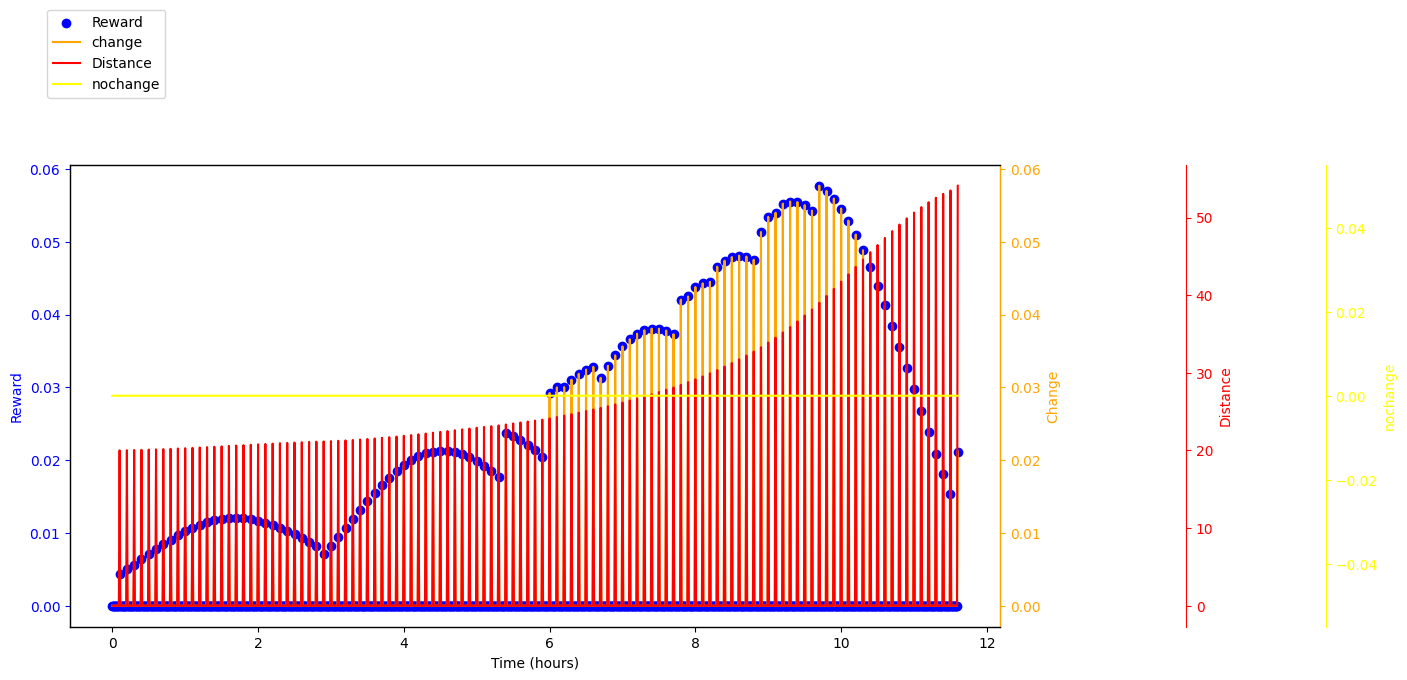

11151334    0.0
11151335    0.0
11151336    0.0
11151337    0.0
11151338    0.0
           ... 
11152490    0.0
11152491    0.0
11152492    0.0
11152493    0.0
11152494    0.0
Name: nochange, Length: 1161, dtype: float64


In [32]:
timesteps = best_result_df['timestep']
reward = best_result_df['reward']
t1 = best_result_df['change']
t2 = best_result_df['distance']
t3 = best_result_df['nochange']
enz_activ = best_result_df['enzyme_activity']

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Reward
ax1.scatter(timesteps/100, reward, color="blue", label="Reward")
ax1.set_ylabel("Reward", color="blue")
ax1.set_xlabel("Time (hours)")
ax1.tick_params(axis='y', colors="blue")

# Plot Change
ax2 = ax1.twinx()
ax2.plot(timesteps/100, t1, color="orange", label="change")
ax2.set_ylabel("Change", color="orange")
ax2.tick_params(axis='y', colors="orange")
ax2.spines['right'].set_color("orange")

# Plot Distance
ax3 = ax1.twinx()
ax3.plot(timesteps/100, t2, color="red", label="Distance")
ax3.spines['right'].set_position(('axes', 1.2))
ax3.set_ylabel("Distance", color="red")
ax3.tick_params(axis='y', colors="red")
ax3.spines['right'].set_color("red")

# Plot nochange
ax4 = ax1.twinx()
ax4.plot(timesteps/100, t3, color="yellow", label="nochange")
ax4.spines['right'].set_position(('axes', 1.35))
ax4.set_ylabel("nochange", color="yellow")
ax4.tick_params(axis='y', colors="yellow")
ax4.spines['right'].set_color("yellow")

fig.legend(loc="upper left", bbox_to_anchor=(0.1, 1.15))
plt.show()
print(t3)



# Training graphs

In [33]:
def get_training_data(last_experiment_number):
    last_experiment_number
    training_rewards = []
    training_experiement_numbers = []
    for experiment_number in range(1, last_experiment_number+1):
        experiment_df = df[df['experiment_number'] == experiment_number]
        rewards = experiment_df['reward']
        reward_sum = sum(rewards)
        training_rewards.append(reward_sum)
        training_experiement_numbers.append(experiment_number) 
    return training_experiement_numbers, training_rewards

def moving_average(data, window_size):
    """Compute the moving average of a dataset."""
    smoothed_data = []
    for i in range(len(data)):
        start = max(0, i - window_size + 1)
        end = i + 1
        subset = data[start:end]
        smoothed_data.append(sum(subset) / len(subset))
    return smoothed_data



In [34]:
ppo_df = pd.read_csv(config.TRAINING_DATA_LOGS_FILENAME)
#a2c_df = pd.read_csv('training_data_a2c.csv')
#dqn_df = pd.read_csv('training_data_dqn.csv')

ppo_last_experiment_number = int(ppo_df['experiment_number'].iloc[-1])
#a2c_last_experiment_number = int(a2c_df['experiment_number'].iloc[-1])
#dqn_last_experiment_number = int(dqn_df['experiment_number'].iloc[-1])

ppo_e_n, ppo_t_r = get_training_data(ppo_last_experiment_number)
#a2c_e_n, a2c_t_r = get_training_data(a2c_last_experiment_number)
#dqn_e_n, dqn_t_r = get_training_data(dqn_last_experiment_number)

In [46]:
# Smoothing window size
window_size = 10

# Apply moving average
ppo_smoothed_reward = moving_average(ppo_t_r, window_size)
# a2c_smoothed_reward = moving_average(a2c_t_r, window_size)
# dqn_smoothed_reward = moving_average(dqn_t_r, window_size)

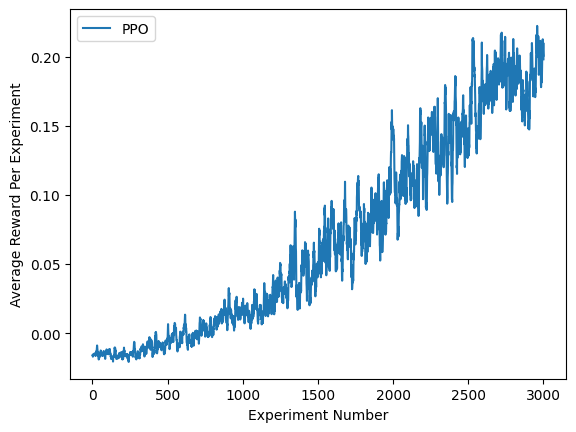

In [47]:
plt.plot(ppo_e_n[:3000], ppo_smoothed_reward[:3000] , label= "PPO", linestyle='-')
plt.xlabel("Experiment Number")
plt.ylabel("Average Reward Per Experiment")
plt.legend()

# Weibull Distribution

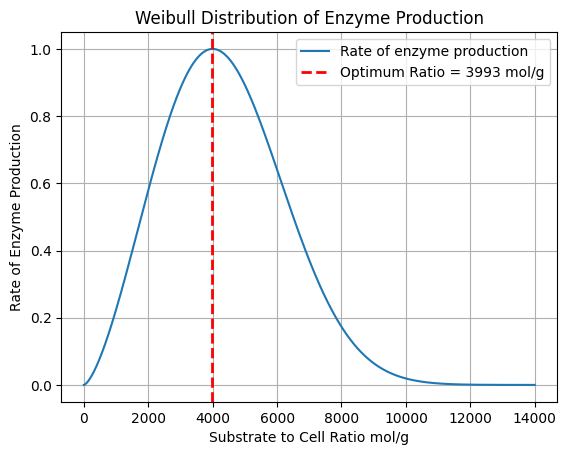

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import weibull_min
import pandas as pd

# Define the shape parameter
k = 2.5 # Smaller shape parameter to widen the curve

# Compute the scale parameter to have a peak at 2500
lambda_ = 4000/ ((k - 1) / k)**(1 / k)

# Generate x values with a wider range
x = np.linspace(0, 14000, 1000)  # Increased range from 0 to 140000

# Compute the PDF
pdf = weibull_min.pdf(x, k, scale=lambda_)

# Normalize the PDF to range from 0 to 1
pdf = pdf / np.max(pdf)

# Find the x value where pdf is maximum
max_index = np.argmax(pdf)
scr_opt = x[max_index]

# Plot the distribution
plt.plot(x, pdf, label='Rate of enzyme production')
plt.xlabel('Substrate to Cell Ratio mol/g')
plt.ylabel('Rate of Enzyme Production')
plt.title('Weibull Distribution of Enzyme Production')
plt.axvline(x=scr_opt, color='r', linestyle='--', linewidth=2, label=f'Optimum Ratio = {int(scr_opt)} mol/g')
#plt.axvline(x=7700, color='g', linestyle='--', linewidth=2, label='Initial SCR = 7700 mol/g')
plt.legend()
plt.grid(True)
plt.show()

dt = {
    'x': x,
    'pdf': pdf
}

df = pd.DataFrame(dt)

df.to_csv('pdfcsv.csv')



In [38]:
from scipy.interpolate import CubicSpline

# Create a cubic spline interpolation model
cs = CubicSpline(x, pdf)

# Define a function to get interpolated value
def get_interpolated_value(new_x):
    return cs(new_x)

print(get_interpolated_value(100))

0.007202159368016426


Text(0.5, 1.0, 'Peak at: 4000.200020002')

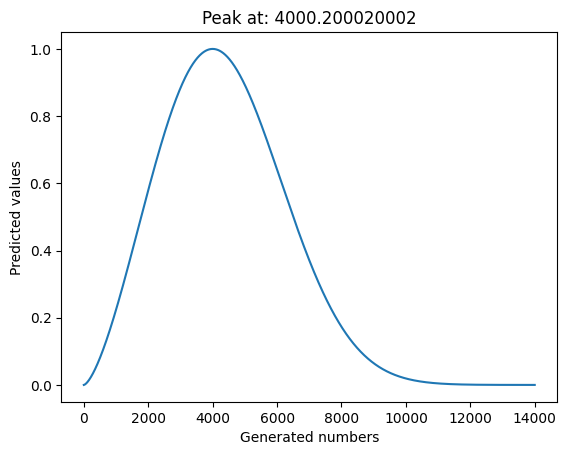

In [39]:
ratio = np.linspace(0, 14000, 10000)

values = []
for i in ratio:
    val = get_interpolated_value(i)
    values.append(val)

plt.plot(ratio, values, label="predicted values")
plt.xlabel("Generated numbers")
plt.ylabel("Predicted values")
plt.title(f"Peak at: {ratio[values.index(max(values))]}")


In [40]:
weibull_values = pd.read_csv('pdfcsv.csv')

weibull_values['x']


0          0.000000
1         14.014014
2         28.028028
3         42.042042
4         56.056056
           ...     
995    13943.943944
996    13957.957958
997    13971.971972
998    13985.985986
999    14000.000000
Name: x, Length: 1000, dtype: float64